# Assignment 3
Interpretability and Bias in ML, University of Göttingen, March 2026

## Part C: Probing Language Models

**Credits**: *Adapted for the InBiML lecture by Jonas Mayer Martins (April 2025). Text and code by Jaap Jumelet (May 2022). Editing & additional questions/assignments by Jelle Zuidema. This notebook makes use of many different libraries including crucially NLTK and Hugging Face's Transformers library, and the trained weights of the RoBERTa-base model and the RoBERTa-base-SST2 version (trained by researchers of FAIR; fine-tuned for the SST-2 dataset of Stanford University, and provided by Hugging Face). RoBERTa is described in this paper: https://arxiv.org/abs/1907.11692.*

*The original notebook for Interpretability & Explainability in AI, MSc A.I., University of Amsterdam, June 2023 is available here: https://github.com/clclab/IEinAI/tree/main/book/week1.*

### Probing
The linguistic dynamics of a language model can be assessed in several ways.
In this task we will focus on using **probing tasks**.
These tasks allow us to *probe* a model's representations using *diagnostic classifiers* ([Hupkes et al. (2018)](https://scholar.google.com/citations?view_op=view_citation&hl=nl&user=tAtSMTcAAAAJ&citation_for_view=tAtSMTcAAAAJ:2osOgNQ5qMEC), also simply referred to as *probes*).
Diagnostic classifiers are simple (i.e. often linear) classifiers that are trained on top of the representations of a model.
This allows us to uncover (linguistic) properties that are encoded in a representation.

Note, however, that the probing paradigm is not restricted to NLP at all, and has been applied in a wide range of application domains, such as chess, vision, and bio-informatics, as has and will be discussed in the lectures. Probing serves as a general tool of uncovering what kind of properties are encoded in the high-dimensional representations of deep neural nets.

## Task
In this short introductory task we will be probing language models for **sentiment**. Sentiment classification is a simple yet common task in NLP, and is nowadays performed as a *fine-tuning* procedure: based on a pre-trained language model we fine-tune the full model on an annotated data set containing sentiment labels. This is often done on a sentence-level, but sentiment of a sentence is the result of a compositional application of sentiment at a lexical level.

You will train probes on the hidden states of a fine-tuned RoBERTa model, to gain insights into how sentiment is represented in these models *across layers*. You will compare these results with the probing results obtained for a *non*-fine-tuned RoBERTa model, i.e. the pre-trained language model that was originally used for fine-tuning it.

This notebook already contains a lot of code to handle the processing of the data, and the extraction of the hidden states of the model, so that you can fully focus on the probing itself.

## ToSubmit: Report
Answers to the questions marked as ToSubmit need to be submitted as part of your report. Take the ToDos and ToThink as additional inspiration.

## Configuration

**Note:** Inference with some models may take long on CPU. You may want to run the notebook locally on your machine or use a cloud-based alternative (Google Colab, ...). Don't forget to enable the GPU runtime (Runtime -> Change runtime type) in Jupyter / Colab / Keggle. Alternatively, to use a GPU with the GWDG JupyterHub (https://jupyter.hpc.gwdg.de/hub/spawn), please contact the tutor to request access.

**Note:** If you are running this locally (not on Google Colab or a pre-configured environment), you might need to install these libraries. Uncomment and run the `!pip install ...` line in the code cell below if needed.

In [21]:
from tqdm import *
from typing import *

import torch
import torch.nn.functional as F

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_built() and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# The natural language dataset

The data we will be using is the SST sentiment treebank, that also contains sentiment labels at the word-level.

<font color='green'><b>ToDo 1</b></font>

Download the corpus, using the following command:

In [22]:
!pip install gdown
# Download a drive folder containing train.txt, dev.txt, and test.txt.
# If you want to do this manually you can find the folder here:
# https://drive.google.com/drive/folders/1UbiuZbIAPq30BvVgB4wg0z6imqaSNiIa?usp=sharing
!gdown --folder 1UbiuZbIAPq30BvVgB4wg0z6imqaSNiIa

Retrieving folder contents
Processing file 1xZveybxnJfryyg-PFLeEuhiAaovyDsa- dev.txt
Processing file 1PcNXZ-QIPvgXsxcB0IMrJiIzYBQJzS16 test.txt
Processing file 13lvRQRKt8XIRS0xtR4d_LOrHWQN44AoK train.txt
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1xZveybxnJfryyg-PFLeEuhiAaovyDsa-
To: /kaggle/working/data/dev.txt
100%|████████████████████████████████████████| 281k/281k [00:00<00:00, 74.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PcNXZ-QIPvgXsxcB0IMrJiIzYBQJzS16
To: /kaggle/working/data/test.txt
100%|█████████████████████████████████████████| 560k/560k [00:00<00:00, 116MB/s]
Downloading...
From: https://drive.google.com/uc?id=13lvRQRKt8XIRS0xtR4d_LOrHWQN44AoK
To: /kaggle/working/data/train.txt
100%|███████████████████████████████████████| 2.16M/2.16M [00:00<00:00, 188MB/s]
Download completed


In [23]:
import nltk

def load_corpus(file_name, is_binary=True):
    with open(file_name) as f:
        raw_trees = f.readlines()

    nltk_trees = [nltk.Tree.fromstring(raw_tree) for raw_tree in raw_trees]

    token_labels = []
    raw_sentences = []
    sentence_labels = []

    for tree in nltk_trees:
        try:
            token_labels.append(extract_token_labels(tree))
            raw_sentences.append(" ".join(tree.leaves()))
            sentence_labels.append(int(tree.label()))
        except AttributeError:
            # There's a few ill-formed trees in the data, we just skip over these
            continue

    return token_labels, raw_sentences, torch.tensor(sentence_labels)


def extract_token_labels(tree):
    """Extracts the token-level sentiments from the tree, recursively. """

    if len(tree) == 1:
        # Leaf has been reached
        return [(tree[0], int(tree.label()))]
    else:
        # Recursively descend into children of current node
        return [
            (item, label)
            for subtree in tree
            for item, label in extract_token_labels(subtree)
        ]

<font color='green'><b>ToDo 2</b></font>

+ Load the corpus, e.g. with
```
all_token_labels, all_sentences, sentence_labels = load_corpus('data/train.txt')
```
+ Look at a couple of sentences; e.g. sentence #117
+ Look at the token labels and determine which of the words have negative ($< 2$) and which have positive sentiment ($>2$).
+ Do the sentence labels always agree with the token labels?



In [24]:
# your code here
all_token_labels, all_sentences, sentence_labels = load_corpus('data/train.txt')
n =15

for i in range(n):
    print((all_token_labels[i]))
    print(all_sentences[i])
    print(sentence_labels[i])
    print("----------")


[('The', 2), ('Rock', 2), ('is', 2), ('destined', 2), ('to', 2), ('be', 2), ('the', 2), ('21st', 2), ('Century', 2), ("'s", 2), ('new', 3), ('``', 2), ('Conan', 2), ("''", 2), ('and', 2), ('that', 2), ('he', 2), ("'s", 2), ('going', 2), ('to', 2), ('make', 2), ('a', 2), ('splash', 3), ('even', 2), ('greater', 3), ('than', 2), ('Arnold', 2), ('Schwarzenegger', 2), (',', 2), ('Jean-Claud', 2), ('Van', 2), ('Damme', 2), ('or', 2), ('Steven', 2), ('Segal', 2), ('.', 2)]
The Rock is destined to be the 21st Century 's new `` Conan '' and that he 's going to make a splash even greater than Arnold Schwarzenegger , Jean-Claud Van Damme or Steven Segal .
tensor(3)
----------
[('The', 2), ('gorgeously', 3), ('elaborate', 2), ('continuation', 2), ('of', 2), ('``', 2), ('The', 2), ('Lord', 2), ('of', 2), ('the', 2), ('Rings', 2), ("''", 2), ('trilogy', 2), ('is', 2), ('so', 2), ('huge', 2), ('that', 2), ('a', 2), ('column', 2), ('of', 2), ('words', 2), ('can', 2), ('not', 1), ('adequately', 3), ('d

<font color='red'><b>ToSubmit 1</b></font>
Include one example sentence (different from the one above) in your report and highlight words with negative and positive sentiment. Select a sentence with both strong positive and negative sentiment on the token level. Explain conceptually how you would arrive at a sentence-level sentiment.

We are only interested in probing the sentiment for words that actually contain sentiment (*great, terrible, mediocre*). To ensure this, we'll create a **mask** that tells us at which positions in our corpus the sentiment words are located. E.g., ```sentiments = (0,4)``` in the function below means that (strongly) negative is defined as the label 0, (strongly) positive is the label 4, the rest is considered neutral by the sentence mask.

Furthermore, for the sake of simplicity we will only be considering words that are not split up into multiple subwords by the model tokenizer. (Current language models, such as the Transformer models that we look at in this notebook, make use of **subword tokenization**, which may split up a longer word into multiple subwords: `"ungrateful"` could become `"un" + "grate" + "ful"`. This makes probing harder, because it's difficult to tell how sentiment is distributed over these multiple subwords - do you take the average or sum or something else to arrive at word-level sentiments? So keep in my that this we employ a rather crude heuristic here for a problem that is important in practice.).

In [25]:
#@title Function to create a mask for sentiment-carrying words (needs access to model's tokenizer)

from tqdm import *

def create_sen_masks(
    input_ids, all_token_labels, tokenizer, sentiments=(0, 4), is_binary=True
):
    """Returns a mask for the sentence positions that have a negative/positive sentiment"""
    all_sen_masks = []
    all_labels = []

    for tokenised_sen, token_labels in tqdm_notebook(zip(input_ids.tolist(), all_token_labels)):
        sen_mask = []
        token_label_dict = dict(token_labels)

        for w_idx, (token_id) in enumerate(tokenised_sen):
            if token_id == 0:
                sen_mask.append(False) # set mask to zero for padding token ID (which has token_id == 0)
                continue

            word = tokenizer.convert_ids_to_tokens(token_id).replace("Ġ", "")
            # Check if this word's sentiment label (if it exists) is in the target sentiments tuple
            if token_label_dict.get(word, -1) in sentiments:
                sen_mask.append(True)
                label = token_label_dict[word]
                if is_binary:
                    label = label > 2 # convert label to binary (0 for (0,1,2) and 1 for (3,4))
                all_labels.append(label)
            else:
                sen_mask.append(False)

        all_sen_masks.append(torch.tensor(sen_mask))

    padded_masks = torch.nn.utils.rnn.pad_sequence(all_sen_masks, batch_first=True)

    return padded_masks, torch.tensor(all_labels)

# Loading the target models

For loading the models we will be making use of Huggingface's transformer library, that has become the de facto standard for transformer models within NLP.

In [26]:
!pip install transformers

import transformers
from transformers import AutoTokenizer, AutoModelForSequenceClassification


def load_model(path):
    tokenizer = AutoTokenizer.from_pretrained(path)
    model = AutoModelForSequenceClassification.from_pretrained(path)
    model.eval()
    model.to(DEVICE)

    return model, tokenizer

## Hidden state extraction

The final step now is to actually extract the hidden states from the language models. We will store these in two separate dictionaries:
- One containing the sentence-level hidden states (at the position of the special `CLS` token, on which the model was fine-tuned)
- One containing the token-level hidden states, filtered by the mask that we created in the previous cell.

Both these dictionaries contain the hidden states at each intermediate layer, starting at the bottom (these are just the input word embeddings), all the way to the top layer.



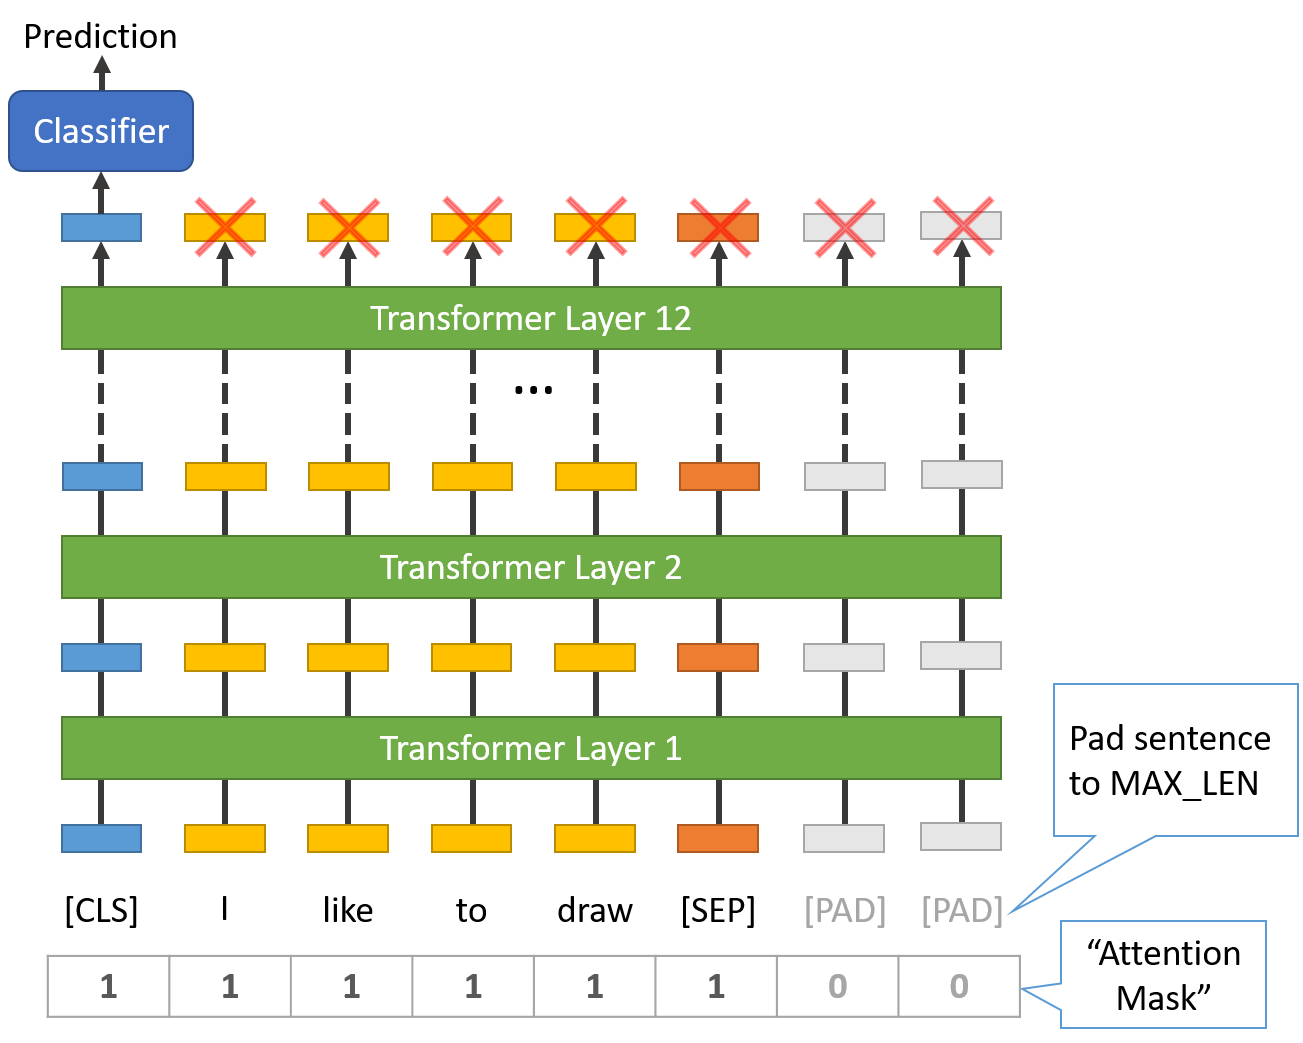

<font color='blue'><b>ToThink 1</b></font>
In the diagram above you see a sketch of the typical Transformer setup for sentence classifications. As indicated, the CLS token in the output layer is typically used to determine the class (e.g. the sentiment class) of the whole sentence. Which other hidden states would be interesting targets for probing?

In [27]:
#@title Key functions for extracting the hidden states (for a given set of sentences)

def extract_hidden_states(
    input_ids, attention_mask, all_sen_masks, num_layers, batch_size=128
):
    token_states = {
        layer_idx: torch.zeros(all_sen_masks.sum(), 768)
        for layer_idx in range(num_layers)
    }

    cls_states = {
        layer_idx: torch.zeros(all_sen_masks.size(0), 768)
        for layer_idx in range(num_layers)
    }

    dataset = torch.utils.data.TensorDataset(input_ids, attention_mask, all_sen_masks)
    data_loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=False
    )

    num_extracted = 0
    sens_extracted = 0
    layer_idx = 0

    for batch_input_ids, batch_attention_mask, batch_sen_mask in tqdm_notebook(
        data_loader, unit="batches"
    ):
        with torch.no_grad():
            all_hidden_states = model(
                batch_input_ids,
                attention_mask=batch_attention_mask,
                output_hidden_states=True,
            ).hidden_states

        for layer_idx, hidden_states in enumerate(all_hidden_states):
            hidden_states_subset = hidden_states[batch_sen_mask]
            subset_size = hidden_states_subset.shape[0]

            token_states[layer_idx][
                num_extracted : num_extracted + subset_size
            ] = hidden_states_subset.cpu()

            cls_states[layer_idx][
                sens_extracted : sens_extracted + batch_size
            ] = hidden_states[:, 0].cpu()

        num_extracted += subset_size
        sens_extracted += batch_size

    return token_states, cls_states

Finally, we create a method that ties all the previous steps together, and that will return the hidden states (on sentence & word level), and the corresponding labels. We will be storing these states and labels in a `data_dict` dictionary object, that contains the data for both the fine-tuned model and the base model.

The original data contains five classes of fine-grained sentiment (including a neutral sentiment, '2'). This fine-grained task is much harder than the binary task, as can be seen in these leaderboards:
- [Binary leaderboard](https://paperswithcode.com/sota/sentiment-analysis-on-sst-2-binary)
- [Fine-grained leaderboard](https://paperswithcode.com/sota/sentiment-analysis-on-sst-5-fine-grained)

We can therefore opt to binarize these labels: i.e., mapping 0 & 1 to a negative label, and 3 & 4 to a positive label. <font color='red'>Please implement this step yourself in the cell below.</font>

In [28]:
#@title Key functions for creating the probing datasets
def preprocess_cls_data(
    cls_states: Dict[int, torch.Tensor], sentence_labels: torch.Tensor, is_binary: bool
):
    # Remove neutral sentences
    for layer_idx, layer_states in cls_states.items():
        cls_states[layer_idx] = layer_states[sentence_labels != 2]

    sentence_labels = sentence_labels[sentence_labels != 2]

    # Map fine-grained sentiments to binary labels
    if is_binary: 
        for i in range(len(sentence_labels)): 
        
            if sentence_labels[i] < 2: 
                sentence_labels[i] = 0
    
            if sentence_labels[i] > 2: 
                sentence_labels[i] = 1

    return cls_states, sentence_labels


def create_probe_data(path, model, tokenizer, num_layers, sentiments, is_binary):
    all_token_labels, all_sentences, sentence_labels = load_corpus(path)

    encoded_corpus = tokenizer(
        all_sentences,
        padding=True,
        truncation=True,
        return_tensors="pt",
    ).to(DEVICE)

    input_ids = encoded_corpus.input_ids
    attention_mask = encoded_corpus.attention_mask

    all_sen_masks, token_labels = create_sen_masks(
        input_ids,
        all_token_labels,
        tokenizer,
        sentiments=sentiments,
        is_binary=is_binary,
    )

    token_states, cls_states = extract_hidden_states(
        input_ids, attention_mask, all_sen_masks, num_layers
    )

    cls_states, sentence_labels = preprocess_cls_data(cls_states, sentence_labels, is_binary)

    return token_states, cls_states, token_labels, sentence_labels

----

<font color='green'><b>ToDo 3</b></font>

+ Download the Transformer library and the two target Transformer models, and run the hidden state extraction code (see the code cell below)
+ Look at some examples of the hidden state tensors you computed.

In [29]:
#@title Compute and store internal states (Note that running this cell may take a few minutes (and again, make sure GPU is enabled!))

sentiments = (0, 1, 3, 4)
is_binary = True

models = [
    ("finetuned", "textattack/roberta-base-SST-2"),
    ("base", "roberta-base"),
]

data_dict = {}


for name, path in models:
    model, tokenizer = load_model(path)

    num_layers = len(model.roberta.encoder.layer) + 1
    print(num_layers)

    train_X, cls_train_X, train_y, cls_train_y = create_probe_data(
        "data/train.txt", model, tokenizer, num_layers, sentiments, is_binary
    )
    test_X, cls_test_X, test_y, cls_test_y = create_probe_data(
        "data/test.txt", model, tokenizer, num_layers, sentiments, is_binary
    )

    data_dict[name] = {
        "train_X": train_X,  # Dictionary mapping layer_idx -> tensor
        "train_y": train_y,
        "test_X": test_X,
        "test_y": test_y,
        "cls_train_X": cls_train_X,
        "cls_train_y": cls_train_y,
        "cls_test_X": cls_test_X,
        "cls_test_y": cls_test_y,
    }


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: textattack/roberta-base-SST-2
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


13


/tmp/ipykernel_59/4260493287.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for tokenised_sen, token_labels in tqdm_notebook(zip(input_ids.tolist(), all_token_labels)):


0it [00:00, ?it/s]

...

13


0it [00:00, ?it/s]

  0%|          | 0/67 [00:00<?, ?batches/s]

0it [00:00, ?it/s]

  0%|          | 0/18 [00:00<?, ?batches/s]



---



## Probing

We have now come to the core of the assignment. The first goal is to probe the sentence-level (`CLS`) states of our model. For the probes you can make use of the `LogisticRegression` class of the `sklearn` module, but a different linear classifier of your liking is fine as well.

You will train a probes on all the intermediate layers as well (that is, a separate probe for each layer, don't train a single probe on all layers at once).

In [30]:
!pip install scikit-learn

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import warnings

warnings.filterwarnings("ignore")


cls_probes = {
    model_name: {
        layer_idx: LogisticRegression(solver="liblinear", penalty="l2", max_iter=10)
        for layer_idx in range(num_layers)
    }
    for model_name in data_dict.keys()
}

cls_probe_results = {
    model_name: []
    for model_name in data_dict.keys()
}

for model_name in cls_probes.keys():
    for layer_idx in range(num_layers):
        # Skip neutral sentence and binarise sentiment classification
        train_X, train_y = (
            data_dict[model_name]["cls_train_X"][layer_idx],
            data_dict[model_name]["cls_train_y"]
        )

        cls_probes[model_name][layer_idx].fit(train_X, train_y)

        test_X, test_y = (
            data_dict[model_name]["cls_test_X"][layer_idx],
            data_dict[model_name]["cls_test_y"]
        )

        test_pred = cls_probes[model_name][layer_idx].predict(test_X)
        test_acc = accuracy_score(test_pred, test_y)

        cls_probe_results[model_name].append(test_acc)

<font color='blue'><b>ToThink 2</b></font>
What differences do you observe between the fine-tuned model and the base model in the results above that do sentence-level probing (i.e., probe at the CLS node of the output layer)

<font color='green'><b>ToDo 4:</b></font>

Now, let's probe for the lexical sentiment. The setup will same as for the `CLS` probe, but now with the word-level hidden states and labels.

(i.e., you need to adapt the code above, such that you do not read ```cls_train_x``` etc. from the probing dataset, but read the internal states from nodes for sentiment-carrying words instead).

In [36]:
# same model structure as above
token_probes = {
    model_name: {
        layer_idx: LogisticRegression(solver="liblinear", penalty="l2", max_iter=10)
        for layer_idx in range(num_layers)
    }
    for model_name in data_dict.keys()
}

token_probe_results = {
    model_name: []
    for model_name in data_dict.keys()
}

for model_name in token_probes.keys():
    for layer_idx in range(num_layers):
        # Skip neutral sentence and binarise sentiment classification
        train_X, train_y = (
            data_dict[model_name]["train_X"][layer_idx], # extract tokens instead of the cls.
            data_dict[model_name]["train_y"]
        )
        
        token_probes[model_name][layer_idx].fit(train_X, train_y)

        test_X, test_y = (
            data_dict[model_name]["test_X"][layer_idx],
            data_dict[model_name]["test_y"]
        )

        test_pred = token_probes[model_name][layer_idx].predict(test_X)
        test_acc = accuracy_score(test_pred, test_y)

        token_probe_results[model_name].append(test_acc)

Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shape of train_X = torch.Size([17602, 768])
Shape of train_y = torch.Size([17602])
Shap

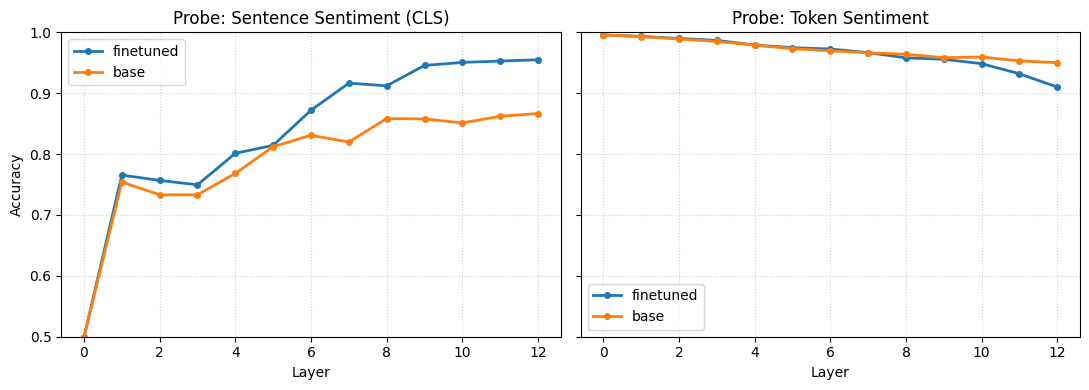

In [37]:
# We took the code from above, just added the token-level figure on the second axis. 
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(11, 4))

# plot 1: cls-accuracy
for model_name, results in cls_probe_results.items():
    axes[0].plot(results, 'o-', lw=2, markersize=4, label=model_name)

axes[0].legend()
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title("Probe: Sentence Sentiment (CLS)")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, linestyle=":", alpha=0.6)

# plot 2: token-accuracy
for model_name, results in token_probe_results.items():
    axes[1].plot(results, 'o-', lw=2, markersize=4, label=model_name)

axes[1].legend()
axes[1].set_title("Probe: Token Sentiment")
axes[1].set_xlabel("Layer")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

<font color='red'><b>ToSubmit 2:</b></font>

Include a plot in your report that shows both the sentence-level (CLS) and the word-level probing results. Add a caption of a few sentences, describing the difference that we observe between both models (sentence vs. lexical).

<font color='blue'><b>ToThink 3:</b></font>
How do you explain differences between the fine-tuned model and the base model?

Finally, we can also use a probe that has been trained on one type of representation (e.g. on `layer #3`), and evaluate that probe on a different representation (e.g. that of `layer #9`).



```
cross_pred = probes["base"][3].predict(data_dict["base"]["test_X"][9])
accuracy_score(cross_pred, data_dict["base"]["test_y"])
```

This procedure is known as cross-evaluation, and it lets us test whether the information about a property (e.g., sentiment, part-of-speech) is encoded similarly at different layers of the model.
If the probe trained on one layer performs well when evaluated on the representations from another layer, this suggests that the encoding of the property is similar (or at least linearly accessible) across those layers.

This gives us insights into how the representation of a property changes across the model: if this is fairly stable cross-evaluating `probe/layer #3` on `layer #9` would give somewhat similar accuracy as evaluating it on `layer #3`.

This idea has been applied earlier by [Giulianelli et al. (2018)](https://arxiv.org/pdf/1808.08079.pdf), in the Temporal Generalization Matrices of Figures 3 and 4, where crossaccuracy across hidden layer activation at different timesteps is computed (whereas here we compute crossaccuracy across different layers).



<font color='green'><b>ToDo 5:</b></font>

Write the code for computing cross-layer accuracy for all combinations of layers.

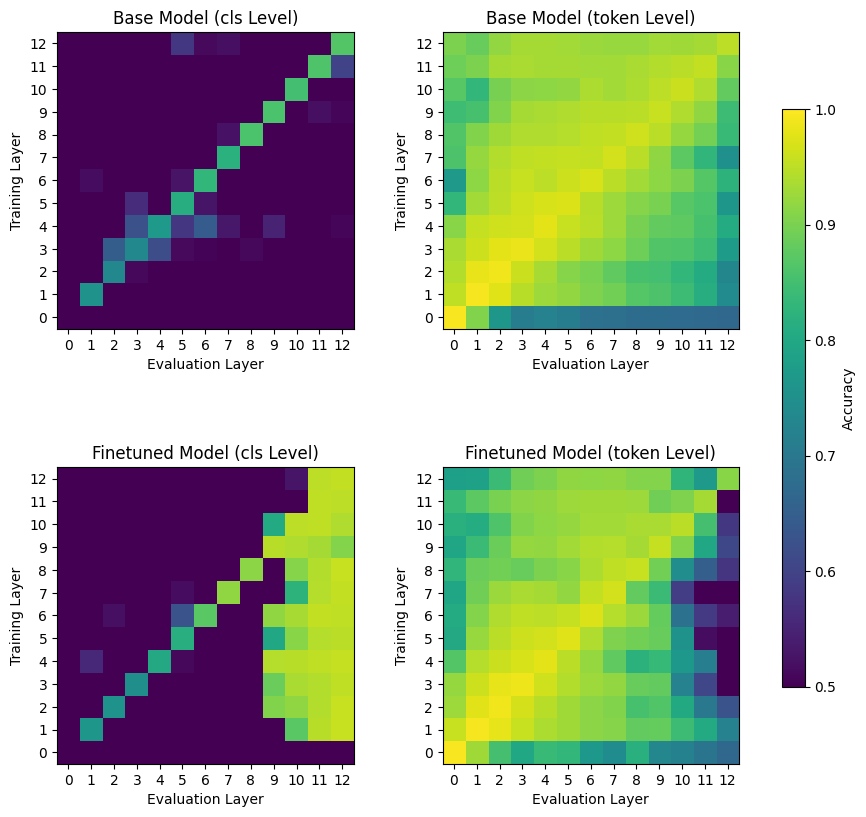

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

configs = [
    ("base", "cls", cls_probes, "cls_test_X", "cls_test_y"),
    ("base", "token", token_probes, "test_X", "test_y"),
    ("finetuned", "cls", cls_probes, "cls_test_X", "cls_test_y"),
    ("finetuned", "token", token_probes, "test_X", "test_y")
]

fig, axes = plt.subplots(2, 2, figsize=(11, 10), gridspec_kw={'hspace': 0.3, 'wspace': 0.3})
axes = axes.flatten()

for idx, (model_name, level, trained_probes, x_key, y_key) in enumerate(configs):
    matrix = np.zeros((num_layers, num_layers))
    raw_y = data_dict[model_name][y_key]
    
    if hasattr(raw_y, "cpu"):
        raw_y = raw_y.cpu().numpy()
    flat_y = raw_y.ravel()
    
    for train_layer in range(num_layers):
        probe = trained_probes[model_name][train_layer]
        
        for eval_layer in range(num_layers):
            raw_X = data_dict[model_name][x_key][eval_layer]
            
            if hasattr(raw_X, "cpu"):
                raw_X = raw_X.detach().cpu().numpy()
            
            test_X = raw_X
            test_y = flat_y
            
            if len(test_y) == len(test_X):
                mask = test_y != -100
                test_X = test_X[mask]
                test_y = test_y[mask]
            
            preds = probe.predict(test_X)
            matrix[train_layer, eval_layer] = accuracy_score(test_y, preds)
            
    ax = axes[idx]
    im = ax.imshow(matrix, cmap="viridis", origin="lower", vmin=0.5, vmax=1.0)
    
    ax.set_title(f"{model_name.capitalize()} Model ({level} Level)")
    ax.set_xlabel("Evaluation Layer")
    ax.set_ylabel("Training Layer")
    ax.set_xticks(range(num_layers))
    ax.set_yticks(range(num_layers))

fig.colorbar(im, ax=axes.tolist(), shrink=0.75, aspect=25, label="Accuracy")

plt.show()

<font color='blue'><b>ToThink 4:</b></font>

How does the representation of sentiment evolve across the layers? What differences do you observe between base and fine-tuned models?

<font color='red'><b>ToSubmit 3:</b></font>
Include in your report a plot of the cross-accuracy matrix (for the combinations of sentence level vs. lexical level and fine-tune vs. pre-trained): the matrix that gives for each combination of layers $<i,j>$ the accuracy of a probe trained on layer $i$ when trying to predict the sentiment at layer $j$. Write a brief caption to the figure that explains in two or three sentences how you intepret the observed pattern of results.

<font color='blue'><b>ToThink 5:</b></font>

1. **Is lexical sentiment better represented linearly in a fine-tuned model than in its base, pre-trained version? How does this compare to sentence-level sentiment?**
2. **Is sentiment information represented stably across layers?**